In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis

In [34]:
df = pd.read_csv(r'D:\Data Analysis\data analysis intern\Task3\Data_Files\Raw_Files\WA_Fn-UseC_-HR-Employee-Attrition.csv')


In [35]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# Clean & Prepare the Data

In [37]:
# ==========================================
# 1. Drop 3 Dead Columns
# ==========================================
# EmployeeCount (always 1), Over18 (always 'Y'), StandardHours (always 80)
dead_columns = ['EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=dead_columns)

In [38]:
# ==========================================
# 2. Create Binary Flags & Fix Data Types
# ==========================================
# Convert Yes/No string columns to numeric 1/0 flags
df['AttritionFlag'] = (df['Attrition'] == 'Yes').astype(int)
df['OverTimeFlag'] = (df['OverTime'] == 'Yes').astype(int)

# Cast key text fields as categorical variables
categorical_cols = [
    'Department', 'JobRole', 'EducationField', 
    'MaritalStatus', 'BusinessTravel', 'Gender'
]
for col in categorical_cols:
    df[col] = df[col].astype('category')

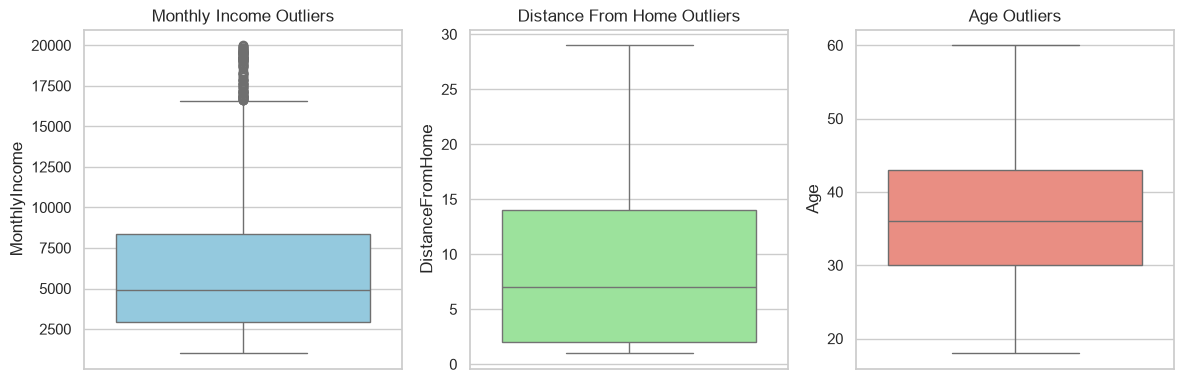

In [39]:
# ==========================================
# 5. Outlier Sanity Check (Boxplots)
# ==========================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['MonthlyIncome'], color='skyblue')
plt.title('Monthly Income Outliers')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['DistanceFromHome'], color='lightgreen')
plt.title('Distance From Home Outliers')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Age'], color='salmon')
plt.title('Age Outliers')

plt.tight_layout()
plt.show()



In [40]:
# ==========================================
# 6. Export Cleaned Dataset
# ==========================================
df.to_csv(r'D:\Data Analysis\data analysis intern\Task3\Data_Files\Cleaned_Files\HR_Cleaned.csv', index=False)

# Department & Job Role Analysis

In [41]:
# ==========================================
# Department Analysis
# ==========================================
dept_summary = df.groupby('Department', observed=False).agg(
    Headcount=('AttritionFlag', 'count'),
    Avg_Monthly_Income=('MonthlyIncome', 'mean'),
    Avg_Tenure_Years=('YearsAtCompany', 'mean'),
    Attrition_Count=('AttritionFlag', 'sum'),
    Attrition_Rate=('AttritionFlag', lambda x: (x.mean() * 100))
).round(2).reset_index()


In [42]:
# ==========================================
# Job Role Analysis
# ==========================================
role_summary = df.groupby(['Department', 'JobRole'], observed=False).agg(
    Headcount=('AttritionFlag', 'count'),
    Avg_Monthly_Income=('MonthlyIncome', 'mean'),
    Avg_Tenure_Years=('YearsAtCompany', 'mean'),
    Attrition_Count=('AttritionFlag', 'sum'),
    Attrition_Rate=('AttritionFlag', lambda x: (x.mean() * 100))
).round(2).reset_index()

In [43]:
# Filter out empty role-department combinations
role_summary = role_summary[role_summary['Headcount'] > 0]

In [44]:
# Display summaries
print("--- Department Summary ---")
dept_summary

--- Department Summary ---


,Department,Headcount,Avg_Monthly_Income,Avg_Tenure_Years,Attrition_Count,Attrition_Rate
0,Human Resources,63,6654.51,7.24,12,19.05
1,Research & Development,961,6281.25,6.86,133,13.84
2,Sales,446,6959.17,7.28,92,20.63


In [45]:
print("\n--- Job Role Summary ---")
role_summary.sort_values(by='Attrition_Rate', ascending=False)


--- Job Role Summary ---


,Department,JobRole,Headcount,Avg_Monthly_Income,Avg_Tenure_Years,Attrition_Count,Attrition_Rate
26,Sales,Sales Representative,83,2626.00,2.92,33,39.76
11,Research & Development,Laboratory Technician,259,3237.17,5.02,62,23.94
1,Human Resources,Human Resources,52,4235.75,5.33,12,23.08
25,Sales,Sales Executive,326,6924.28,7.50,57,17.48
15,Research & Development,Research Scientist,292,3239.97,5.11,47,16.10
13,Research & Development,Manufacturing Director,145,7295.14,7.60,10,6.90
9,Research & Development,Healthcare Representative,131,7528.76,8.37,9,6.87
12,Research & Development,Manager,54,17130.33,13.52,3,5.56
21,Sales,Manager,37,16986.97,15.22,2,5.41
14,Research & Development,Research Director,80,16033.55,10.94,2,2.50


# Satisfaction Analysis

In [46]:
# ==========================================
# 1. Compensation & Experience Correlations
# ==========================================
corr_cols = ['MonthlyIncome', 'JobLevel', 'TotalWorkingYears', 'PerformanceRating', 'PercentSalaryHike']
correlation_matrix = df[corr_cols].corr()

print("--- Correlation Matrix ---")
print(correlation_matrix[['MonthlyIncome', 'PercentSalaryHike']].round(3))

--- Correlation Matrix ---
                   MonthlyIncome  PercentSalaryHike
MonthlyIncome              1.000             -0.027
JobLevel                   0.950             -0.035
TotalWorkingYears          0.773             -0.021
PerformanceRating         -0.017              0.774
PercentSalaryHike         -0.027              1.000


In [47]:
# ==========================================
# 2. Performance Rating Distribution Analysis
# ==========================================
perf_counts = df['PerformanceRating'].value_counts().sort_index()
print("\n--- Performance Rating Counts ---")
print(perf_counts)


--- Performance Rating Counts ---
PerformanceRating
3    1244
4     226
Name: count, dtype: int64


In [48]:
# ==========================================
# 3. Percent Salary Hike Breakdown by Department & Job Role
# ==========================================
dept_hike = df.groupby('Department', observed=False)['PercentSalaryHike'].agg(
    Mean_Hike='mean', Median_Hike='median', Min_Hike='min', Max_Max='max'
).round(2).reset_index()


print("\n--- Salary Hike by Department ---")
dept_hike



--- Salary Hike by Department ---


,Department,Mean_Hike,Median_Hike,Min_Hike,Max_Max
0,Human Resources,14.76,14.0,11,23
1,Research & Development,15.29,14.0,11,25
2,Sales,15.10,14.0,11,25


In [49]:
role_hike = df.groupby('JobRole', observed=False)['PercentSalaryHike'].agg(
    Mean_Hike='mean', Median_Hike='median', Min_Hike='min', Max_Hike='max'
).round(2).reset_index()

In [50]:
print("\n--- Salary Hike by Job Role ---")
role_hike.sort_values(by='Mean_Hike', ascending=False)


--- Salary Hike by Job Role ---


,JobRole,Mean_Hike,Median_Hike,Min_Hike,Max_Hike
8,Sales Representative,15.67,15.0,11,25
4,Manufacturing Director,15.59,15.0,11,25
0,Healthcare Representative,15.45,14.0,11,25
6,Research Scientist,15.45,14.0,11,25
3,Manager,15.14,14.0,11,25
2,Laboratory Technician,15.05,14.0,11,25
5,Research Director,14.95,14.0,11,25
7,Sales Executive,14.89,14.0,11,25
1,Human Resources,14.81,14.0,11,23


C:\Users\Mega Store\AppData\Local\Temp\ipykernel_11536\1049272155.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='PerformanceRating', y='PercentSalaryHike', palette='Set2')


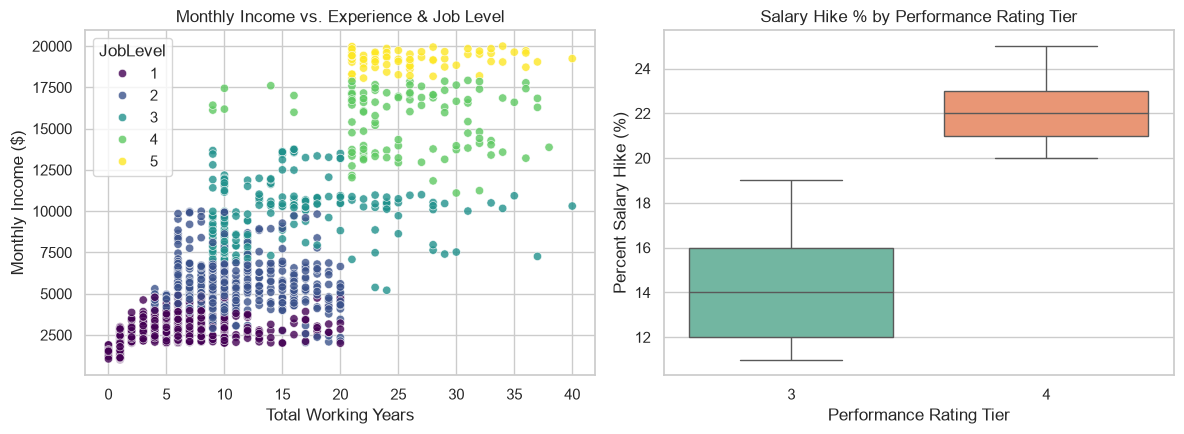

In [51]:
# ==========================================
# 4. Generate & Save Charts
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Chart 1: Income vs Total Working Years colored by Job Level
sns.scatterplot(
    ax=axes[0], data=df, x='TotalWorkingYears', y='MonthlyIncome', 
    hue='JobLevel', palette='viridis', alpha=0.8
)
axes[0].set_title('Monthly Income vs. Experience & Job Level')
axes[0].set_xlabel('Total Working Years')
axes[0].set_ylabel('Monthly Income ($)')

# Chart 2: Percent Salary Hike by Performance Rating Tier
sns.boxplot(ax=axes[1], data=df, x='PerformanceRating', y='PercentSalaryHike', palette='Set2')
axes[1].set_title('Salary Hike % by Performance Rating Tier')
axes[1].set_xlabel('Performance Rating Tier')
axes[1].set_ylabel('Percent Salary Hike (%)')

plt.tight_layout()
plt.show()